# Carregamento do DataSet

In [98]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply, ReplaceInfWithNan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os 

In [99]:
df = load(filenames)
df = apply(df)
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Preprocessamento

In [100]:
class_map = {
    'BENIGN': 'Benign',
    'DoS slowloris': 'Slow HTTP',
    'DoS Slowhttptest': 'Slow HTTP',
    'DoS Hulk': 'HTTP Flood',
    'DoS GoldenEye': 'HTTP Flood',
}

In [101]:
df = df[df['Label'].isin(['BENIGN','DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'] = df['Label'].map(class_map)
df['Label'].value_counts()

Label
Benign        2273097
HTTP Flood     241366
Slow HTTP       11295
Name: count, dtype: int64

In [102]:
# Remove valores nulos e infinitos da base
df.replace([np.inf, -np.inf], np.nan, inplace=True)

linhas_antes = len(df)
valores_nulos_antes = int(df.isna().sum().sum())

df.dropna(inplace=True)

print(f"Linhas antes: {linhas_antes}")
print(f"Valores nulos/inf convertidos para NaN: {valores_nulos_antes}")
print(f"Linhas após limpeza: {len(df)}")
print(f"Total de NaN restantes: {int(df.isna().sum().sum())}")

Linhas antes: 2525758
Valores nulos/inf convertidos para NaN: 5452
Linhas após limpeza: 2523032
Total de NaN restantes: 0


In [103]:
df.drop(columns=["Destination Port"], inplace=True)

In [104]:
cols = df.columns.drop("Label", errors="ignore")

colunas_quase_constantes = []

for col in cols:
    # conta a proporção do valor mais frequente
    proporcao_maior_valor = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    
    if proporcao_maior_valor > 0.99:
        colunas_quase_constantes.append(col)

print("\nColunas com mais de 99% de um único valor:")
print(colunas_quase_constantes)

# remove do dataframe
df = df.drop(columns=colunas_quase_constantes, errors="ignore")

print(f"\nTotal de colunas removidas: {len(colunas_quase_constantes)}")


Colunas com mais de 99% de um único valor:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Total de colunas removidas: 12


In [105]:
#Remover a coluna "Fwd Header Length.1" por ser idêntica à "Fwd Header Length"
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)
    print("Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.")

Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.


# Analise do Dataset

In [106]:
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


# Treinamento Modelo


In [107]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Class"] = label_encoder.fit_transform(df["Label"].astype(str))

mapa_classes = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Class": range(len(label_encoder.classes_))
})

display(mapa_classes)

,Label,Class
0,Benign,0
1,HTTP Flood,1
2,Slow HTTP,2


In [108]:
df.drop(columns=["Label"], inplace=True)

In [110]:
selected_features = [
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Duration",
    "Flow Packets/s",
    "Flow Bytes/s",
    "Down/Up Ratio",
    "Class"
]
df = df[selected_features]

In [111]:
df

,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Duration,Flow Packets/s,Flow Bytes/s,Down/Up Ratio,Class
0,2,0,12,0,3,666666.666700,4.000000e+06,0,0
1,1,1,6,6,109,18348.623850,1.100917e+05,1,0
2,1,1,6,6,52,38461.538460,2.307692e+05,1,0
3,1,1,6,6,34,58823.529410,3.529412e+05,1,0
4,2,0,12,0,3,666666.666700,4.000000e+06,0,0
...,...,...,...,...,...,...,...,...,...
692698,4,2,112,152,32215,186.248642,8.194940e+03,0,0
692699,2,2,84,362,324,12345.679010,1.376543e+06,1,0
692700,2,1,31,6,82,36585.365850,4.512195e+05,0,0
692701,6,2,192,256,1048635,7.628965,4.272221e+02,0,0


## Separação Treino/Teste


In [129]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Class'])

In [132]:
df_train[df_train["Class"] == 2].describe()

,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Duration,Flow Packets/s,Flow Bytes/s,Down/Up Ratio,Class
count,9036.000000,9036.000000,9036.000000,9036.000000,9.036000e+03,9.036000e+03,9.036000e+03,9036.000000,9036.0
mean,6.069168,1.324037,657.025896,67.299801,5.736288e+07,1.296687e+04,1.046940e+07,0.268482,2.0
std,4.739451,1.323460,1133.990222,403.863386,4.363467e+07,9.620149e+04,9.424767e+07,0.603684,0.0
min,1.000000,0.000000,0.000000,0.000000,1.000000e+00,2.588999e-02,0.000000e+00,0.000000,2.0
25%,2.000000,0.000000,0.000000,0.000000,3.003485e+06,1.108606e-01,0.000000e+00,0.000000,2.0
50%,4.000000,1.000000,11.000000,0.000000,6.312035e+07,1.560553e-01,1.600016e-01,0.000000,2.0
75%,7.000000,3.000000,539.000000,0.000000,1.026780e+08,9.989075e-01,2.480678e+01,0.000000,2.0
max,23.000000,12.000000,5720.000000,14556.000000,1.198007e+08,2.000000e+06,1.980000e+09,4.000000,2.0


In [134]:
df_test[df_test["Class"] == 2].describe()

,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Duration,Flow Packets/s,Flow Bytes/s,Down/Up Ratio,Class
count,2259.000000,2259.000000,2259.000000,2259.000000,2.259000e+03,2.259000e+03,2.259000e+03,2259.000000,2259.0
mean,5.959717,1.298362,660.660912,71.800797,5.615751e+07,1.311815e+04,1.091842e+07,0.288623,2.0
std,4.731560,1.298105,1154.531718,346.663960,4.364768e+07,9.767736e+04,9.645799e+07,0.645149,0.0
min,1.000000,0.000000,0.000000,0.000000,1.000000e+00,2.589026e-02,0.000000e+00,0.000000,2.0
25%,2.000000,0.000000,0.000000,0.000000,3.003241e+06,1.108638e-01,0.000000e+00,0.000000,2.0
50%,4.000000,1.000000,8.000000,0.000000,6.311890e+07,1.624040e-01,1.600014e-01,0.000000,2.0
75%,7.000000,3.000000,539.000000,0.000000,1.026578e+08,9.990005e-01,2.481423e+01,0.000000,2.0
max,19.000000,4.000000,5720.000000,1983.000000,1.197368e+08,2.000000e+06,1.980000e+09,4.000000,2.0


In [124]:
def remover_outliers_iqr(df, colunas=None, multiplicador=1.5):
    """
    Remove outliers usando o método IQR.
    
    multiplicador=1.5 -> usa o método padrão de Tukey
    multiplicador=3.0 -> mais conservador, remove menos outliers
    """
    if colunas is None:
        colunas = df.select_dtypes(include=['int64', 'float64']).columns
    
    df_filtrado = df.copy()
    
    for col in colunas:
        Q1 = df_filtrado[col].quantile(0.25)
        Q3 = df_filtrado[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inferior = Q1 - multiplicador * IQR
        limite_superior = Q3 + multiplicador * IQR
        
        df_filtrado = df_filtrado[(df_filtrado[col] >= limite_inferior) & 
                                   (df_filtrado[col] <= limite_superior)]
    
    return df_filtrado

# Remover outliers do df_train (excluindo a coluna 'Class')
colunas_numericas = df_train.columns.drop("Class")
df_train = remover_outliers_iqr(df_train, colunas=colunas_numericas, multiplicador=1.5)

print(f"Linhas após remoção de outliers: {len(df_train)}")

Linhas após remoção de outliers: 694317


## Balanceamento

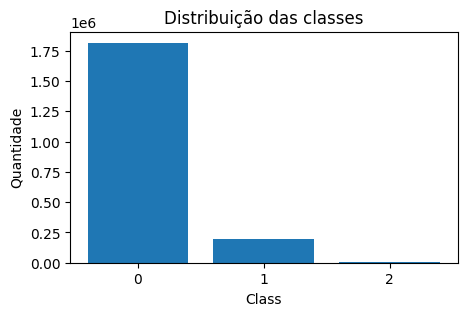

In [113]:
def plot_class_distribution(df, class_col="Class"):
    counts = df[class_col].value_counts().sort_index()
    plt.figure(figsize=(5,3))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribuição das classes")
    plt.xlabel("Class")
    plt.ylabel("Quantidade")
    plt.show()
plot_class_distribution(df_train)

In [114]:
df_train['Class'].value_counts()

Class
0    1817055
1     192334
2       9036
Name: count, dtype: int64

In [115]:
from imblearn.under_sampling import RandomUnderSampler

def aplicar_undersampling_por_proporcao(
    df,
    target_col="Class",
    proporcao=10,
    classe_referencia=None,
    random_state=42
):
    """
    Aplica undersampling no DataFrame inteiro e retorna apenas o DataFrame balanceado.

    proporcao=10 -> classes majoritárias terão no máximo 10x a quantidade da menor classe
    proporcao=20 -> classes majoritárias terão no máximo 20x a quantidade da menor classe
    """

    class_counts = df[target_col].value_counts()

    if classe_referencia is None:
        menor_qtd = class_counts.min()
    else:
        menor_qtd = class_counts[classe_referencia]

    limite = menor_qtd * proporcao

    sampling_strategy = {
        classe: min(qtd, limite)
        for classe, qtd in class_counts.items()
    }

    rus = RandomUnderSampler(
        sampling_strategy=sampling_strategy,
        random_state=random_state
    )

    df_bal, _ = rus.fit_resample(
        df,
        df[target_col]
    )

    return df_bal

In [116]:
df_train_bal = aplicar_undersampling_por_proporcao(
    df_train,
    target_col="Class",
    proporcao=10
)

df_train_bal["Class"].value_counts()


Class
0    90360
1    90360
2     9036
Name: count, dtype: int64

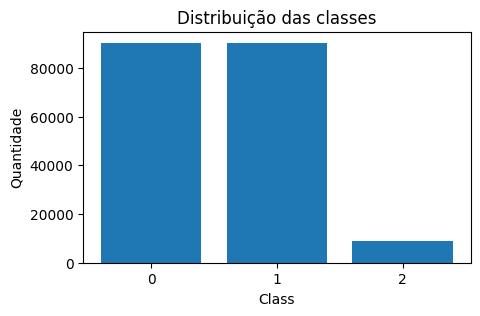

In [117]:
plot_class_distribution(df_train_bal)

# Treinamento

In [119]:
X_train = df_train.drop(columns=["Class"])
X_train_bal = df_train_bal.drop(columns=["Class"])

y_train = df_train["Class"]
y_train_bal = df_train_bal["Class"]

X_test = df_test.drop(columns=["Class"])
y_test = df_test["Class"]

## Random Forest

In [120]:
from sklearn.ensemble import RandomForestClassifier
import time

randomForest = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1, class_weight='balanced')
start = time.time()
randomForest.fit(X_train, y_train)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 74.65 segundos


## Feature Selection

In [23]:
from sklearn.inspection import permutation_importance



randomForest.fit(X_train, y_train)

result = permutation_importance(
    randomForest,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="f1_weighted"
)

importances = result.importances_mean

In [24]:
feat_imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
}).sort_values("importance", ascending=False)

feat_imp

,feature,importance,std
52,Init_Win_bytes_forward,0.026296,0.000112
30,Fwd Header Length,0.011454,0.000033
55,min_seg_size_forward,0.005095,0.000067
53,Init_Win_bytes_backward,0.004970,0.000051
43,URG Flag Count,0.002312,0.000054
...,...,...,...
22,Fwd IAT Max,-0.000026,0.000009
18,Flow IAT Min,-0.000026,0.000006
0,Flow Duration,-0.000027,0.000006
17,Flow IAT Max,-0.000032,0.000004


In [47]:
from sklearn.ensemble import RandomForestClassifier
import time

randomForest_bal = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
start = time.time()
randomForest_bal.fit(X_train_bal, y_train_bal)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 8.69 segundos


### Salvar RandomForest


In [28]:
import joblib
import os 

#Cria a pasta modelo caso não exista
os.makedirs("modelo", exist_ok=True)

# Salvar o modelo treinado
joblib.dump(randomForest, "./modelo/random_forest.joblib")
joblib.dump(randomForest_bal, "./modelo/random_forest_balanced.joblib")

# Salvar o LabelEncoder
joblib.dump(label_encoder, "modelo/label_encoder.joblib")

# Salvar o scaler
#joblib.dump(scaler, "modelo/minmax_scaler.joblib")

['modelo/label_encoder.joblib']

In [121]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": randomForest.feature_importances_
}).sort_values("importance", ascending=False)

importances.to_csv("importances_random_forest2.csv", index=False)

## Avaliação do Modelo

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

def show_classification_metrics(y_true, y_pred):
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão gráfica
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão')
    plt.show()

def plot_roc_auc(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR (False Positive Rate)')
    plt.ylabel('TPR (True Positive Rate)')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()
    print(f'AUC: {auc:.4f}')

Acurácia: 0.9814350573812888
Precisão: 0.9840485064748283
Recall: 0.9814350573812888
F1 Score: 0.9820883989633667

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    454265
           1       0.84      0.99      0.91     48083
           2       0.97      0.97      0.97      2259

    accuracy                           0.98    504607
   macro avg       0.94      0.98      0.96    504607
weighted avg       0.98      0.98      0.98    504607



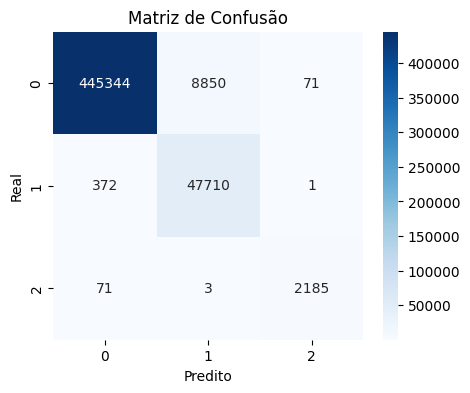

In [122]:
y_predict = randomForest.predict(X_test)
show_classification_metrics(y_test, y_predict)

In [ ]:
from sklearn.metrics import classification_report

relatorio = classification_report(
    y_test,
    y_predict,
    output_dict=True,
    zero_division=0
)

print("Precisão Macro:", relatorio["macro avg"]["precision"])
print("Recall Macro:", relatorio["macro avg"]["recall"])
print("F1 Macro:", relatorio["macro avg"]["f1-score"])

In [35]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


def comparar_modelos_multiclasse(
    modelo_1,
    modelo_2,
    X_test,
    y_test,
    nome_1="Modelo 1",
    nome_2="Modelo 2"
):
    """
    Compara dois modelos de classificação multiclasse no conjunto de teste.

    Retorna:
    - tabela_agregada: métricas gerais dos modelos
    - tabela_por_classe: métricas por classe para cada modelo
    """

    modelos = {
        nome_1: modelo_1,
        nome_2: modelo_2
    }

    resultados_agregados = []
    resultados_por_classe = []

    for nome, modelo in modelos.items():
        y_pred = modelo.predict(X_test)

        # Métricas agregadas
        resultados_agregados.append({
            "Modelo": nome,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision Macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "Recall Macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "F1 Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Precision Weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "Recall Weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1 Weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        })

        # Métricas por classe
        report = classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        for classe, metricas in report.items():
            if classe in ["accuracy", "macro avg", "weighted avg"]:
                continue

            resultados_por_classe.append({
                "Modelo": nome,
                "Classe": classe,
                "Precision": metricas["precision"],
                "Recall": metricas["recall"],
                "F1-score": metricas["f1-score"],
                "Support": metricas["support"]
            })

    tabela_agregada = pd.DataFrame(resultados_agregados).set_index("Modelo")

    tabela_por_classe = pd.DataFrame(resultados_por_classe)
    tabela_por_classe = tabela_por_classe.set_index(["Modelo", "Classe"])

    return tabela_agregada, tabela_por_classe

In [40]:
tabela_agregada, tabela_por_classe = comparar_modelos_multiclasse(
    randomForest,
    xgboost,
    X_test,
    y_test,
    nome_1="random Forest",
    nome_2="XGBoost"
)

display(tabela_agregada)
display(tabela_por_classe)

,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
Modelo,,,,,,,
random Forest,0.999386,0.987537,0.995686,0.991492,0.999392,0.999386,0.999388
XGBoost,0.998617,0.963247,0.978856,0.970768,0.998639,0.998617,0.998625


Precision    Recall  F1-score   Support
Modelo        Classe                                         
random Forest 0        0.999668  0.999687  0.999678  419012.0
              1        0.996590  0.994652  0.995620    2057.0
              2        0.997885  0.996355  0.997119   34569.0
              3        0.945405  0.993308  0.968765    1046.0
              4        0.998136  0.994429  0.996279    1077.0
XGBoost       0        0.999227  0.999303  0.999265  419012.0
              1        0.976778  0.981526  0.979146    2057.0
              2        0.997532  0.993694  0.995609   34569.0
              3        0.882405  0.954111  0.916858    1046.0
              4        0.960295  0.965645  0.962963    1077.0